In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_contacts)=
# Get contacts

*Computing contact maps and inter-atomic contact matrices.*

The function {func}`molsysmt.structure.get_contacts` calculates a boolean contact matrix or a list of interacting atom pairs where the Euclidean distance is below a specified cutoff threshold.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.structure.get_contacts`.
:::


## Basic usage

Let's compute and plot the C-alpha contact map of TcTIM (PDB ID: 1TCD):


In [2]:
import molsysmt as msm
import numpy as np
import matplotlib.pyplot as plt


In [3]:
molsys = msm.convert(msm.systems['TcTIM']['1tcd.h5msm'])


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We select all C-alpha atoms and compute contacts using a threshold of `1.2 nm`:


In [4]:
ca_atoms = msm.select(molsys, selection='atom_name=="CA"')
contact_map = msm.structure.get_contacts(molsys, selection=ca_atoms, threshold='1.2 nm')


In [5]:
print('Contact map shape:', contact_map.shape)
print(f'Total contacts: {np.sum(contact_map)}')


Contact map shape: (1, 497, 497)
Total contacts: 16609


We display the 2D contact matrix using Matplotlib:


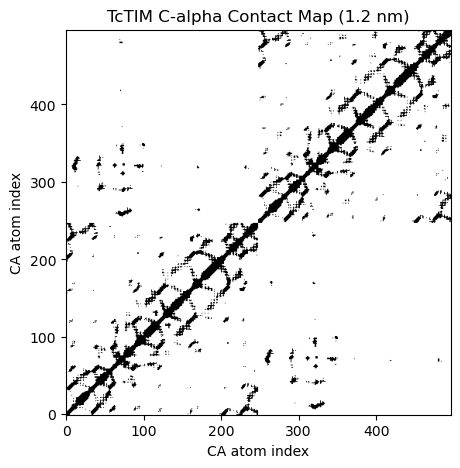

In [6]:
plt.figure(figsize=(5, 5))
plt.imshow(contact_map[0], cmap='Greys', origin='lower')
plt.title('TcTIM C-alpha Contact Map (1.2 nm)')
plt.xlabel('CA atom index')
plt.ylabel('CA atom index')
plt.show()


## Inter-chain contact map

We can compute contacts across different selections, such as between the two chains of the homodimer:


In [7]:
ca_chain_0 = msm.select(molsys, selection='atom_name=="CA" and chain_index==0')
ca_chain_1 = msm.select(molsys, selection='atom_name=="CA" and chain_index==1')
interchain = msm.structure.get_contacts(molsys, selection=ca_chain_0, selection_2=ca_chain_1, threshold='1.0 nm')


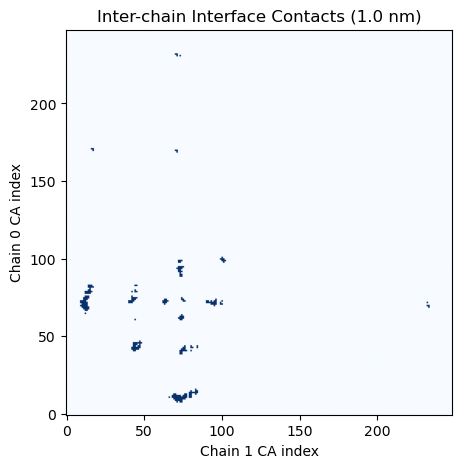

In [8]:
plt.figure(figsize=(5, 5))
plt.imshow(interchain[0], cmap='Blues', origin='lower')
plt.title('Inter-chain Interface Contacts (1.0 nm)')
plt.xlabel('Chain 1 CA index')
plt.ylabel('Chain 0 CA index')
plt.show()


## Extracting contact pairs

Setting `output_type='pairs'` returns the explicit list of interacting atom pairs directly:


In [9]:
pairs_list = msm.structure.get_contacts(molsys, selection=ca_atoms, threshold='1.2 nm', output_type='pairs')
print('Total interacting pairs:', len(pairs_list[0]))
print('First 5 contact pairs [i, j]:', pairs_list[0][:5])


Total interacting pairs: 8056
First 5 contact pairs [i, j]: [[0, 1], [0, 2], [0, 3], [0, 4], [0, 33]]


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems between different forms with {func}`molsysmt.basic.convert`.
- {ref}`Select <Tutorial_Select>`: Query atom or group indices using {func}`molsysmt.basic.select`.
- {ref}`Show contacts <Tutorial_Show_contacts>`: Plot contact maps and interactive matrix visualizations with {func}`molsysmt.structure.show_contacts`.
- {ref}`Get distances <Tutorial_Get_distances>`: Measure numerical distances between pairs of atoms with {func}`molsysmt.structure.get_distances`.
:::
